# **MARKET ANALYSIS**
The telecommunications industry is one of the most competitive sectors globally, with operators constantly competing for subscribers through pricing, network quality, service bundles, and customer experience. As market saturation increases, retaining existing customers has become more cost-effective than acquiring new ones. Consequently, customer churn has emerged as a major business challenge for telecom operators worldwide. Research indicates that the telecommunications industry experiences some of the highest churn rates among major industries, often exceeding 30% annually.

Telecom companies generate massive volumes of customer data from call records, billing systems, internet usage, customer service interactions, and subscription activities. Business Intelligence (BI) and Machine Learning technologies provide an opportunity to transform this data into actionable insights that can identify customers at risk of leaving before churn occurs. Predictive analytics enables telecom operators to implement targeted retention strategies, personalized offers, and proactive customer support.
The growth of mobile data services, 5G adoption, and digital communication platforms has increased customer expectations regarding service quality, network reliability, and pricing transparency. Customers can easily switch providers when dissatisfied with network performance, billing practices, or customer service. Studies have shown that factors such as service quality, pricing structures, device availability, and customer experience significantly influence churn behavior.

For telecom companies, customer churn directly affects revenue, profitability, and market share. High churn rates create revenue leakage and increase customer acquisition costs because attracting a new customer is significantly more expensive than retaining an existing one. Modern telecom operators are therefore investing in predictive analytics and machine learning solutions to identify at-risk customers before they leave. Predictive churn management enables companies to implement proactive retention strategies such as personalized offers, loyalty programs, and service improvements.

Recent studies demonstrate that machine learning techniques such as LightGBM, XGBoost, Random Forest, and neural networks can effectively predict churn behavior by analyzing customer usage patterns, spending behavior, network experience, and demographic characteristics. These technologies allow organizations to transform large volumes of customer data into actionable business intelligence that supports strategic decision-making and customer retention initiatives.

Given the increasing competition in the telecom market and the financial impact of customer attrition, there is a growing demand for intelligent churn prediction systems that help organizations improve customer retention, enhance customer lifetime value, and sustain long-term profitability.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing  import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

In [13]:
!pip install catboost

In [14]:
from catboost import CatBoostClassifier

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Import the dataset from your google drive
record=pd.read_csv('/content/drive/MyDrive/ColabNotebooks/GCIFINALASSESMENT/Record.csv')
client=pd.read_csv('/content/drive/MyDrive/ColabNotebooks/GCIFINALASSESMENT/Client.csv')

In [17]:
total_data= pd.merge( record, client, on='Customer_ID', how ='outer')

# **HANDLING OF NAN VALUES**

In [18]:
#  Handling of the NAN for numerical Variables

# Handling the numerical columns
mean_nan_cols=['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean','ovrrev_Mean', 'vceovr_Mean','datovr_Mean', 'roam_Mean','change_mou', 'change_rev','ovrmou_Mean','avg6mou', 'avg6qty','avg6rev', 'numbcars', 'models', 'hnd_price', 'eqpdays']
impute=SimpleImputer(strategy='mean')
total_data[mean_nan_cols]=impute.fit_transform(total_data[mean_nan_cols])

# Handling the categorical columns

most_frequent= ['prizm_social_one', 'area','refurb_new','dualband','truck', 'rv', 'ownrent','dwlltype','marital', 'adults', 'income','HHstatin','dwllsize', 'ethnic', 'forgntvl' ]


imputer= SimpleImputer(strategy='most_frequent')
total_data[most_frequent]= imputer.fit_transform(total_data[most_frequent])

total_data['hnd_webcap']= total_data['hnd_webcap'].fillna('NoWeb')

total_data[['phones', 'models']]=total_data[['phones', 'models']].fillna(0)
total_data['lor']=total_data['lor'].fillna(0)


In [19]:
total_data['months'].min()

6

In [20]:
total_data['months'].max()

61

# **EXPLORATORY DATA ANALYSIS**

/tmp/ipykernel_1096/3550048224.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_count = total_data.groupby('month_group')['churn'].sum()


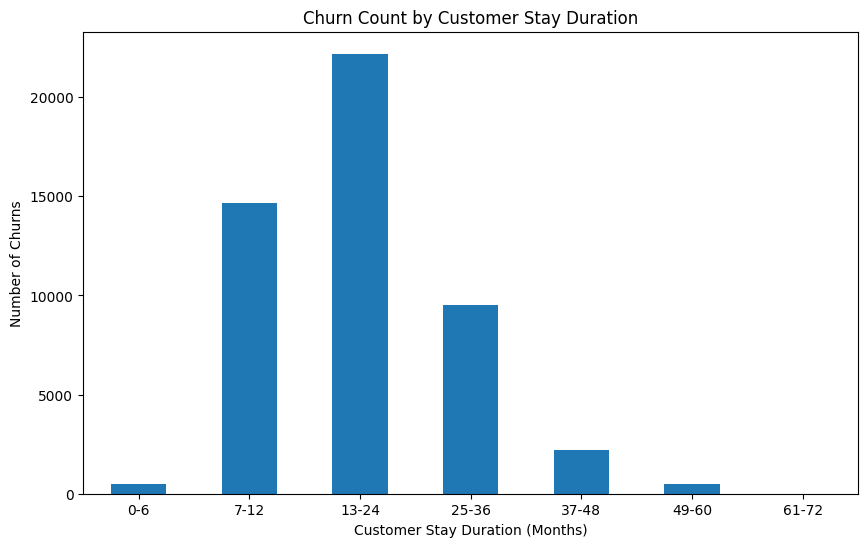

In [21]:


# Example:
# months = customer stay duration
# churn = 1 means customer churned, 0 means stayed

# Create month groups (bins)
total_data['month_group'] = pd.cut(
    total_data['months'],
    bins=[0, 6, 12, 24, 36, 48, 60, 72],
    labels=[
        '0-6',
        '7-12',
        '13-24',
        '25-36',
        '37-48',
        '49-60',
        '61-72'
    ]
)

# Count number of churns in each group
churn_count = total_data.groupby('month_group')['churn'].sum()

# Plot
plt.figure(figsize=(10,6))

churn_count.plot(
    kind='bar'
)

plt.xlabel("Customer Stay Duration (Months)")
plt.ylabel("Number of Churns")
plt.title("Churn Count by Customer Stay Duration")

plt.xticks(rotation=0)

plt.show()

In [22]:
total_data['eqpdays'].max()

1823.0

In [23]:
total_data['eqpdays'].min()

-5.0

/tmp/ipykernel_1096/1948780156.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_count = total_data.groupby('eqp_year_group')['churn'].sum()


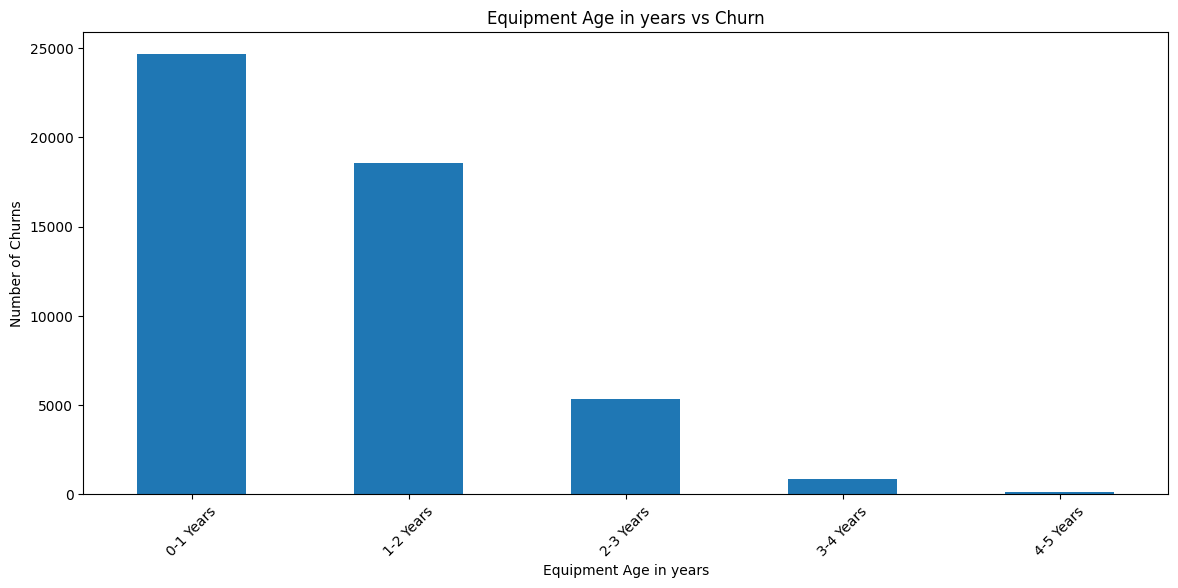

In [24]:
max_days = int(total_data['eqpdays'].max())

bins = range(0, max_days + 365, 365)

labels = [
    f"{i}-{i+1} Years"
    for i in range(len(bins)-1)
]

total_data['eqp_year_group'] = pd.cut(
    total_data['eqpdays'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Churn count
churn_count = total_data.groupby('eqp_year_group')['churn'].sum()

# Plot
plt.figure(figsize=(14,6))

churn_count.plot(kind='bar')

plt.xlabel("Equipment Age in years")
plt.ylabel("Number of Churns")
plt.title("Equipment Age in years vs Churn")

plt.xticks(rotation=45)

plt.show()

In [25]:
total_data['totrev'].max()

27321.5

In [26]:
total_data['totrev'].min()

3.65

In [27]:
area_counts = total_data['area'].value_counts()
display(area_counts)

,count
area,
NEW YORK CITY AREA,11138
LOS ANGELES AREA,6636
DC/MARYLAND/VIRGINIA AREA,6567
MIDWEST AREA,6346
SOUTHWEST AREA,6187
ATLANTIC SOUTH AREA,6132
CALIFORNIA NORTH AREA,5913
NEW ENGLAND AREA,5452
DALLAS AREA,5426


/tmp/ipykernel_1096/3083978625.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_count = total_data.groupby(


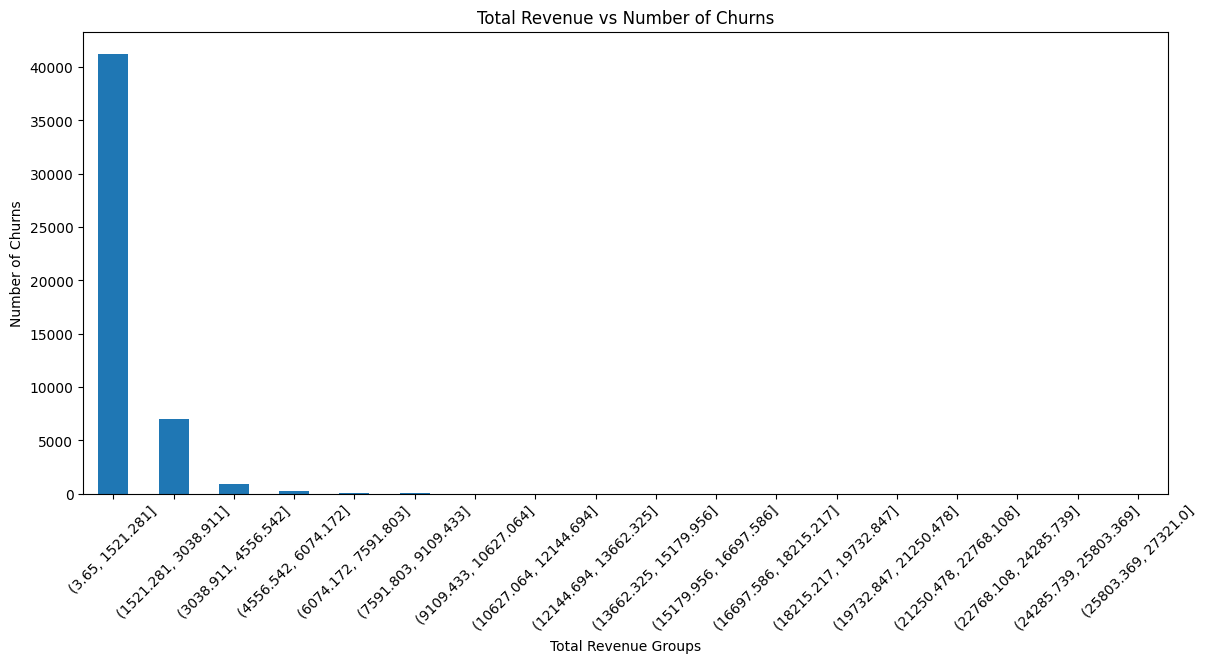

In [28]:


# Create 18 revenue groups
bins = np.linspace(3.65, 27321, 19)

# Group total revenue into intervals
total_data['revenue_group'] = pd.cut(
    total_data['totrev'],
    bins=bins
)

# Count churns in each revenue group
churn_count = total_data.groupby(
    'revenue_group'
)['churn'].sum()

# Plot
plt.figure(figsize=(14,6))

churn_count.plot(
    kind='bar'
)

plt.xlabel("Total Revenue Groups")
plt.ylabel("Number of Churns")
plt.title("Total Revenue vs Number of Churns")

plt.xticks(rotation=45)

plt.show()

/tmp/ipykernel_1096/3563976831.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_count = total_data.groupby(


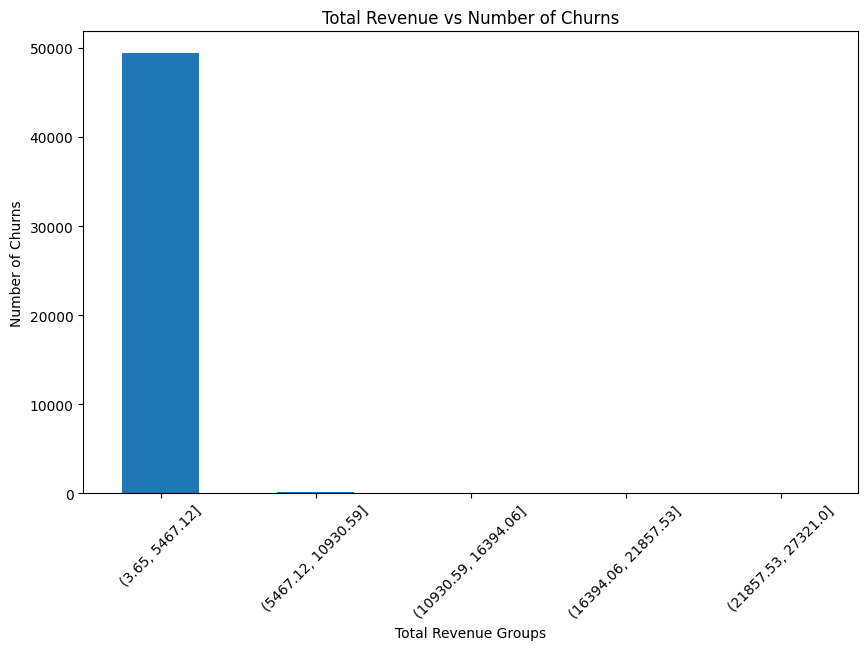

In [29]:


# Divide total revenue into 5 groups
bins = np.linspace(3.65, 27321, 6)

# Create revenue groups
total_data['revenue_group'] = pd.cut(
    total_data['totrev'],
    bins=bins
)

# Count churns in each group
churn_count = total_data.groupby(
    'revenue_group'
)['churn'].sum()

# Plot
plt.figure(figsize=(10,6))

churn_count.plot(kind='bar')

plt.xlabel("Total Revenue Groups")
plt.ylabel("Number of Churns")
plt.title("Total Revenue vs Number of Churns")

plt.xticks(rotation=45)

plt.show()

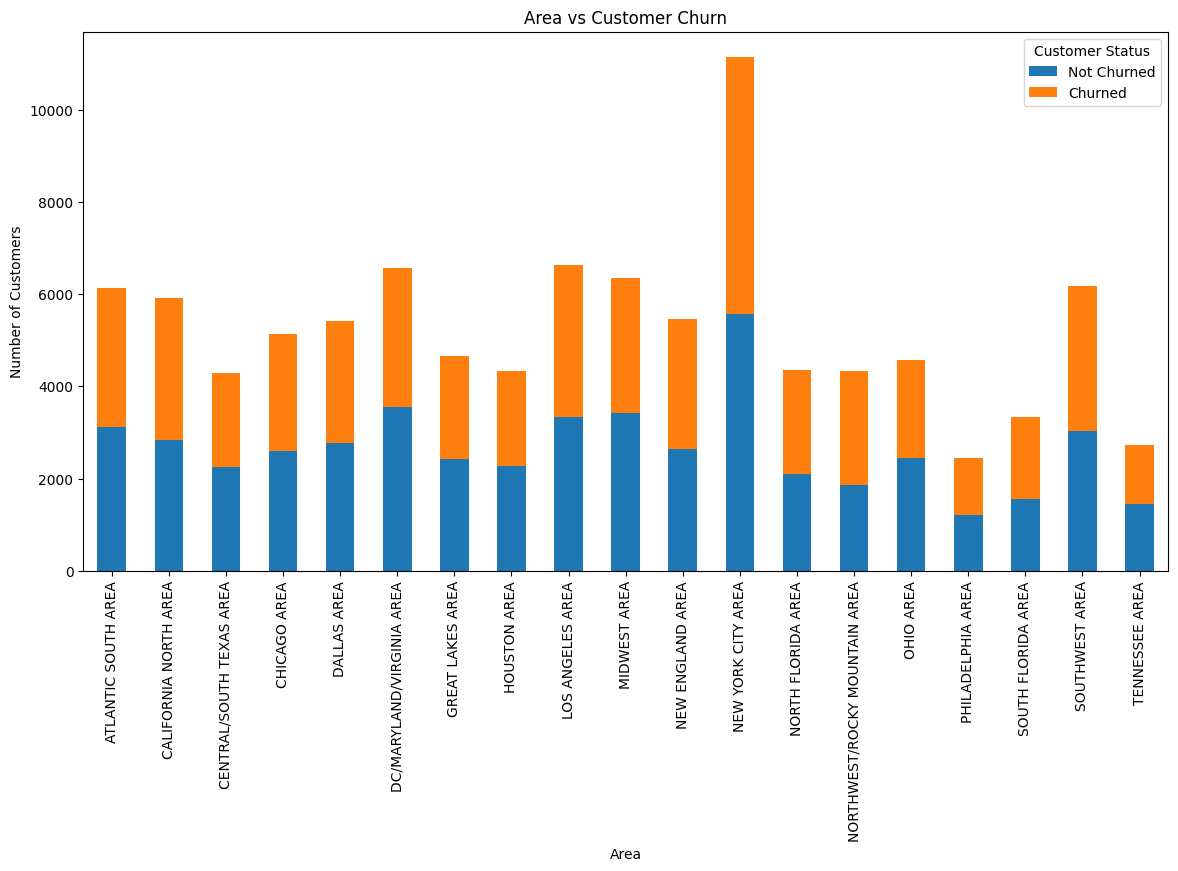

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by area and churn
area_churn = total_data.groupby(['area', 'churn']).size().unstack()

# Rename columns for readability
area_churn.columns = ['Not Churned', 'Churned']

# Plot
area_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.xlabel("Area")
plt.ylabel("Number of Customers")
plt.title("Area vs Customer Churn")

plt.xticks(rotation=90)

plt.legend(title='Customer Status')

plt.show()

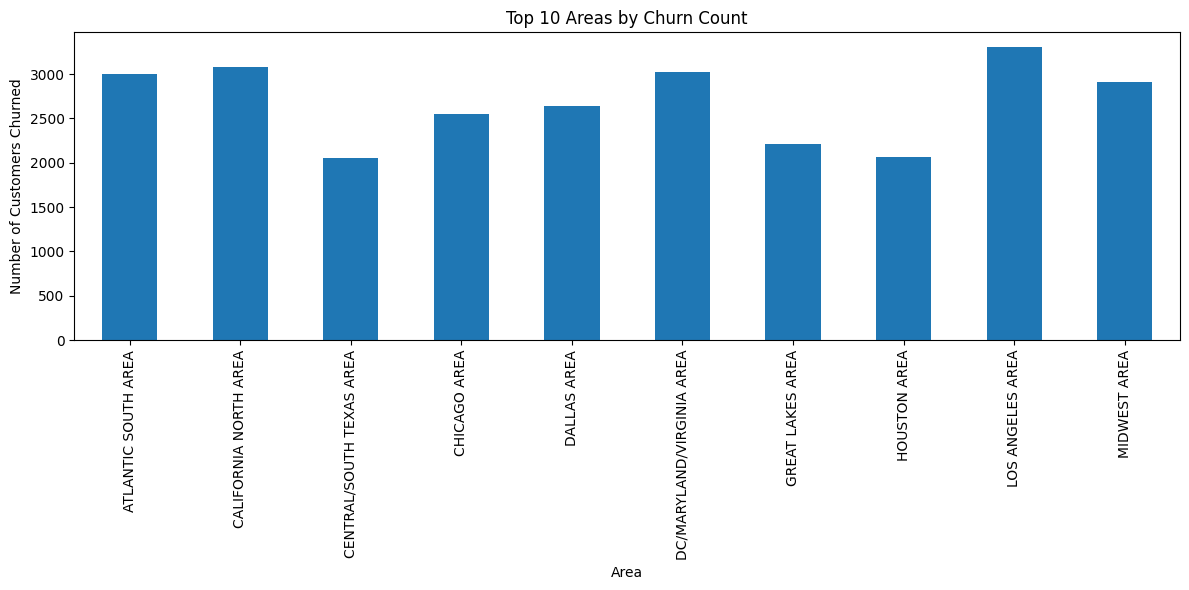

In [31]:
area_churn = (
    total_data[total_data['churn'] == 1]
    .groupby('area')
    .size()

    .head(10)
)

plt.figure(figsize=(12, 6))
area_churn.plot(kind='bar')

plt.xlabel("Area")
plt.ylabel("Number of Customers Churned")
plt.title("Top 10 Areas by Churn Count")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

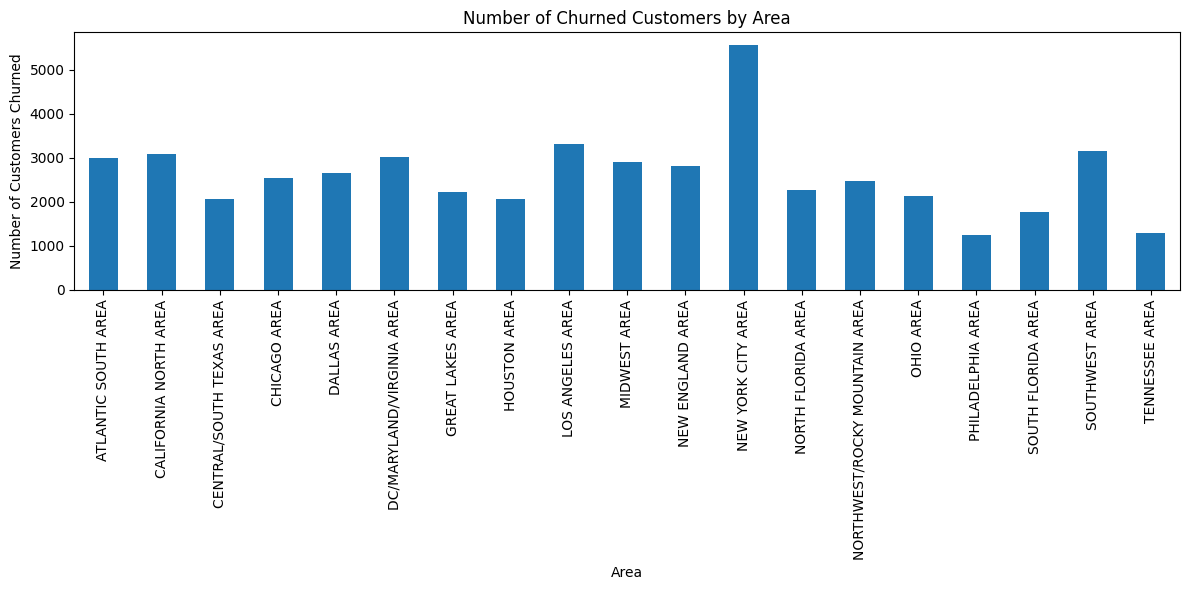

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Count churned customers by area
area_churn = (
    total_data[total_data['churn'] == 1]
    .groupby('area')
    .size()

)

# Plot
plt.figure(figsize=(12, 6))

area_churn.plot(kind='bar')

plt.xlabel("Area")
plt.ylabel("Number of Customers Churned")
plt.title("Number of Churned Customers by Area")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

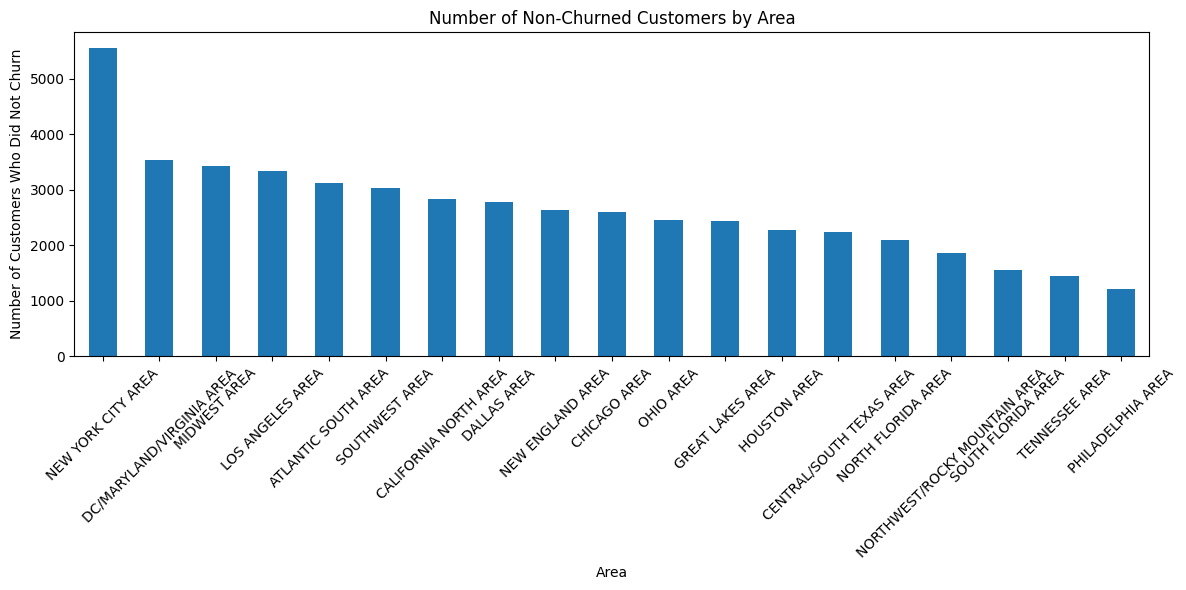

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Count customers that did NOT churn by area
area_not_churn = (
    total_data[total_data['churn'] == 0]
    .groupby('area')
    .size()
    .sort_values(ascending=False)
)


plt.figure(figsize=(12, 6))

area_not_churn.plot(kind='bar')

plt.xlabel("Area")
plt.ylabel("Number of Customers Who Did Not Churn")
plt.title("Number of Non-Churned Customers by Area")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

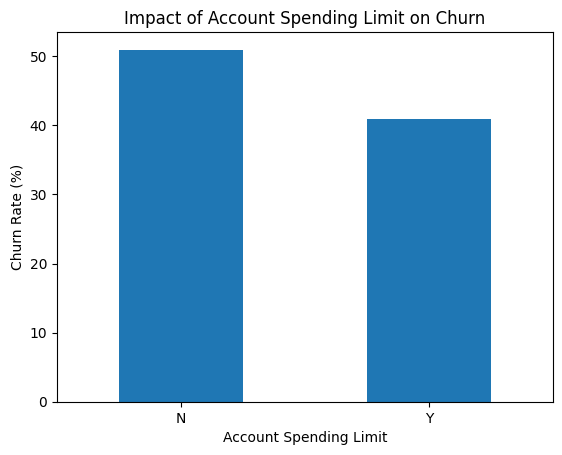

In [34]:
import matplotlib.pyplot as plt

churn_rate = (
    total_data.groupby('asl_flag')['churn']
    .mean()
    .mul(100)
)

churn_rate.plot(kind='bar')

plt.xlabel("Account Spending Limit")
plt.ylabel("Churn Rate (%)")
plt.title("Impact of Account Spending Limit on Churn")

plt.xticks(rotation=0)
plt.show()

/tmp/ipykernel_1096/3768636135.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = total_data.groupby('revenue_group')['churn'].mean() * 100


<Axes: xlabel='revenue_group'>

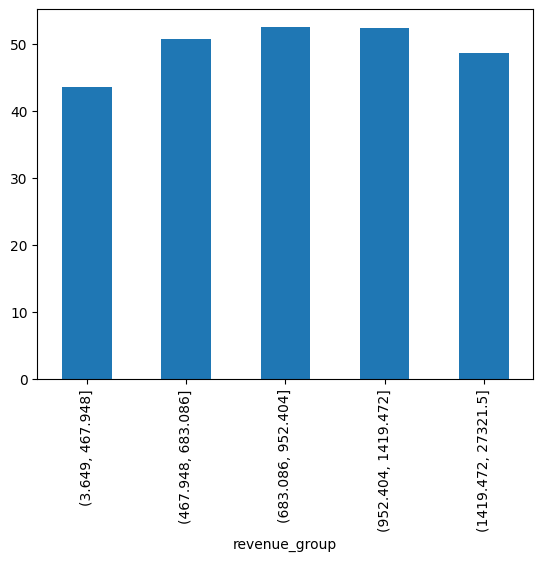

In [35]:
total_data['revenue_group'] = pd.qcut(
    total_data['totrev'],
    q=5
)

churn_rate = total_data.groupby('revenue_group')['churn'].mean() * 100
churn_rate.plot(kind='bar')

<Axes: xlabel='new_cell'>

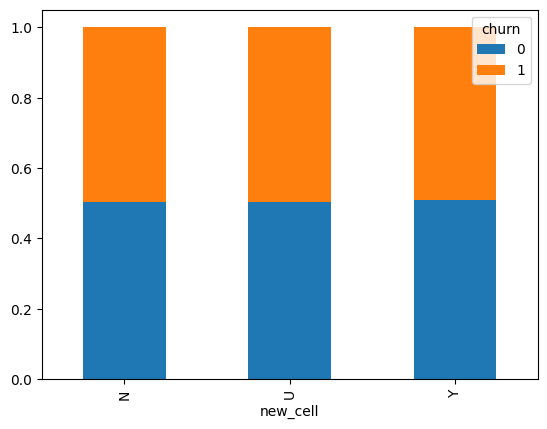

In [36]:
pd.crosstab(
    total_data['new_cell'],
    total_data['churn'],
    normalize='index'
).plot(kind='bar', stacked=True)

<Axes: xlabel='asl_flag'>

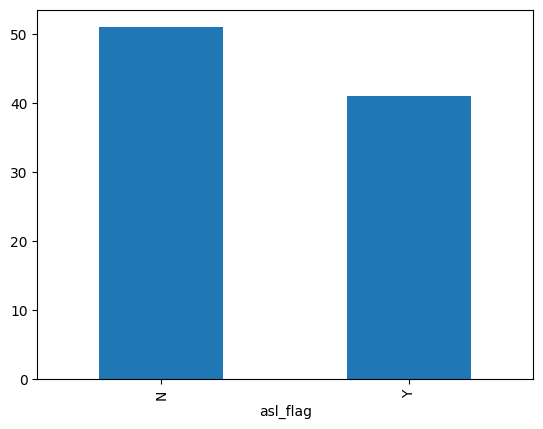

In [37]:
asl = total_data.groupby('asl_flag')['churn'].mean()*100
asl.plot(kind='bar')

/tmp/ipykernel_1096/2032766574.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = total_data.groupby('usage_group')['churn'].mean()*100


<Axes: xlabel='usage_group'>

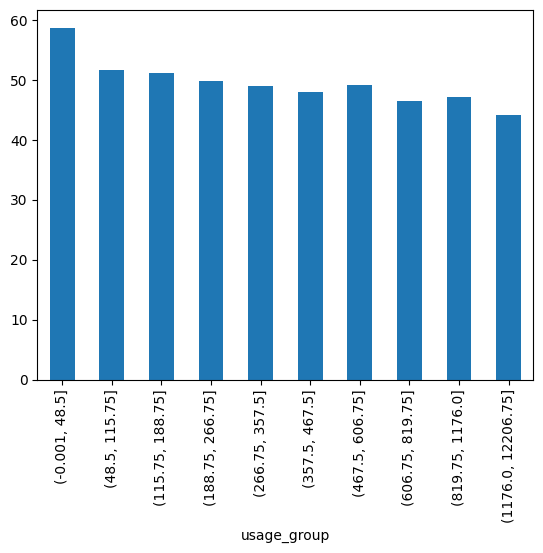

In [38]:
total_data['usage_group'] = pd.qcut(
    total_data['mou_Mean'],
    q=10
)

churn_rate = total_data.groupby('usage_group')['churn'].mean()*100
churn_rate.plot(kind='bar')

In [39]:
# import pandas as pd

# importance = pd.Series(
#     rf_model.feature_importances_,
#     index=X.columns
# ).sort_values(ascending=False)

# importance.head(15).plot(kind='barh')

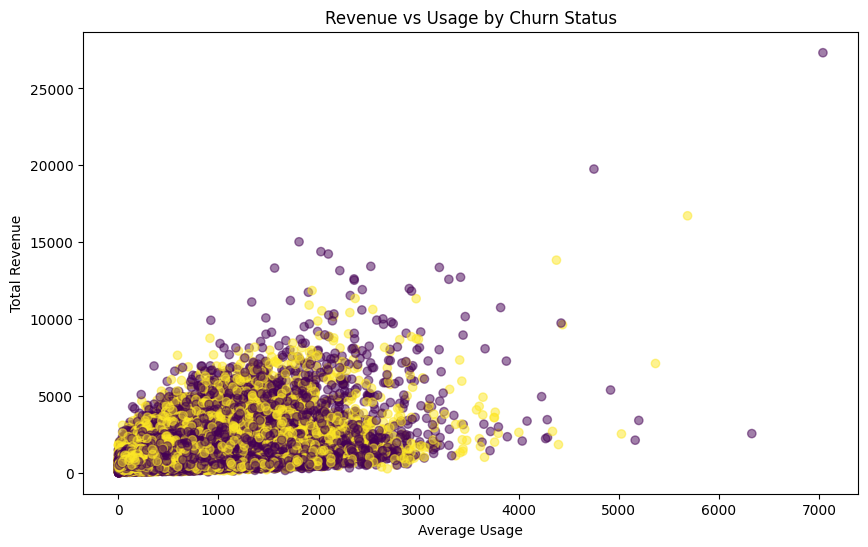

In [40]:
plt.figure(figsize=(10,6))

plt.scatter(
    total_data['avgmou'],
    total_data['totrev'],
    c=total_data['churn'],
    alpha=0.5
)

plt.xlabel('Average Usage')
plt.ylabel('Total Revenue')
plt.title('Revenue vs Usage by Churn Status')

plt.show()

/tmp/ipykernel_1096/302639549.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arpu = total_data.groupby('tenure_group')['totrev'].mean()


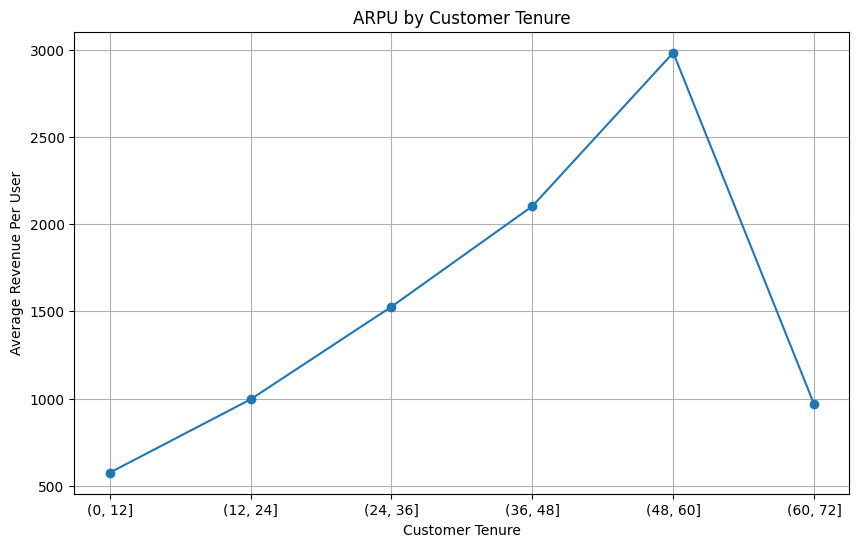

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Create tenure groups
total_data['tenure_group'] = pd.cut(
    total_data['months'],
    bins=[0, 12, 24, 36, 48, 60, 72]
)

# Average revenue per customer in each group
arpu = total_data.groupby('tenure_group')['totrev'].mean()

# Plot
plt.figure(figsize=(10,6))
arpu.plot(kind='line', marker='o')

plt.xlabel('Customer Tenure')
plt.ylabel('Average Revenue Per User')
plt.title('ARPU by Customer Tenure')
plt.grid(True)

plt.show()

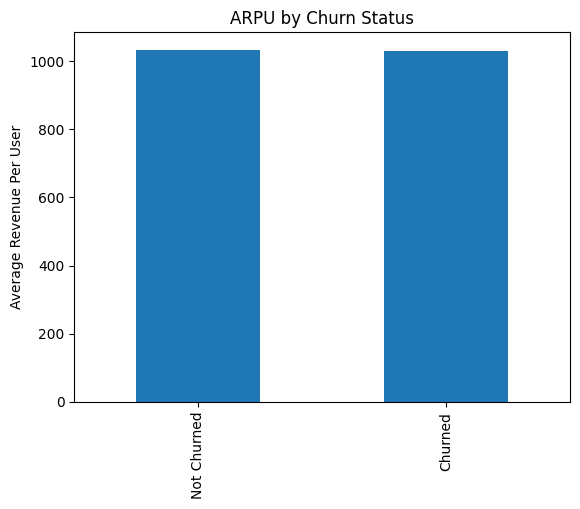

In [42]:
import matplotlib.pyplot as plt

arpu_churn = total_data.groupby('churn')['totrev'].mean()

arpu_churn.index = ['Not Churned', 'Churned']

arpu_churn.plot(kind='bar')

plt.ylabel('Average Revenue Per User')
plt.title('ARPU by Churn Status')

plt.show()

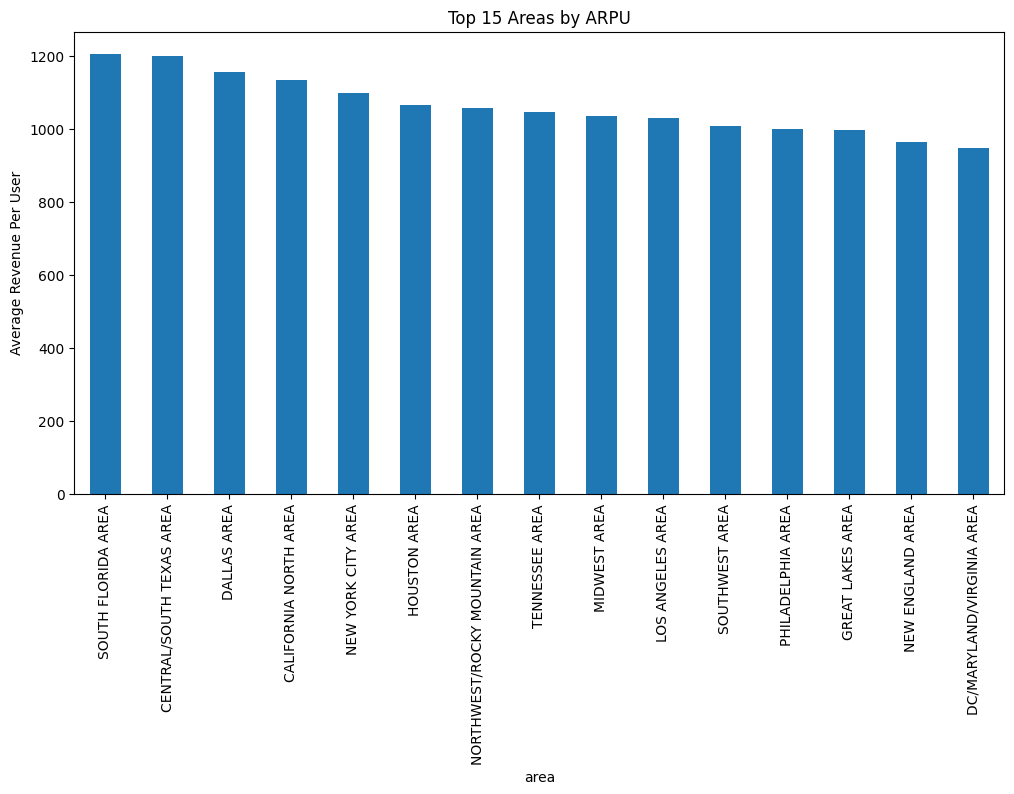

In [43]:
arpu_area = (
    total_data.groupby('area')['totrev']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

arpu_area.plot(kind='bar', figsize=(12,6))

plt.ylabel('Average Revenue Per User')
plt.title('Top 15 Areas by ARPU')

plt.show()

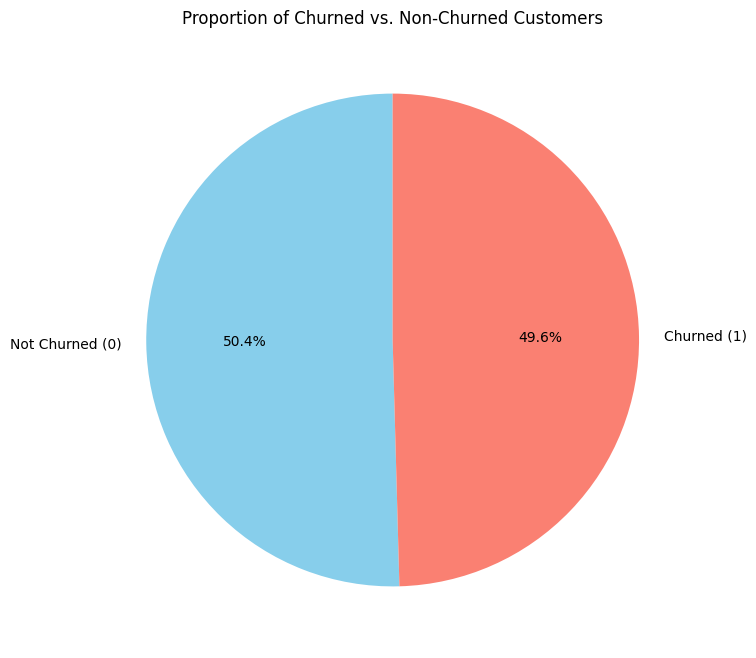

In [44]:
churn_counts = total_data['churn'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    churn_counts,
    labels=['Not Churned (0)', 'Churned (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'salmon']
)
plt.title('Proportion of Churned vs. Non-Churned Customers')
plt.show()

/tmp/ipykernel_1096/2708233915.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = total_data.groupby('totrev_group')['churn'].mean() * 100


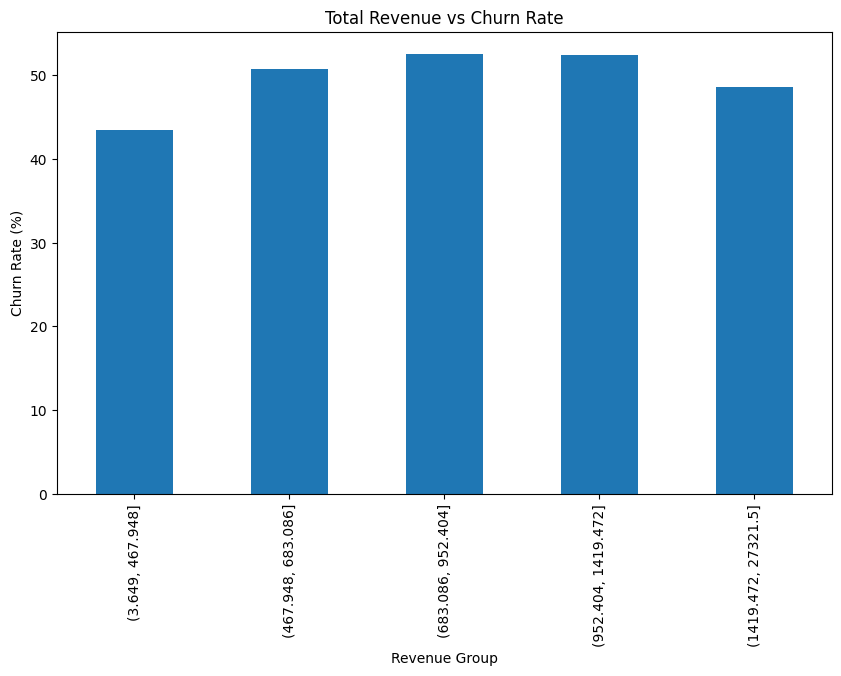

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

total_data['totrev_group'] = pd.qcut(total_data['totrev'], q=5)

churn_rate = total_data.groupby('totrev_group')['churn'].mean() * 100

plt.figure(figsize=(10,6))
churn_rate.plot(kind='bar')

plt.title('Total Revenue vs Churn Rate')
plt.xlabel('Revenue Group')
plt.ylabel('Churn Rate (%)')
plt.show()

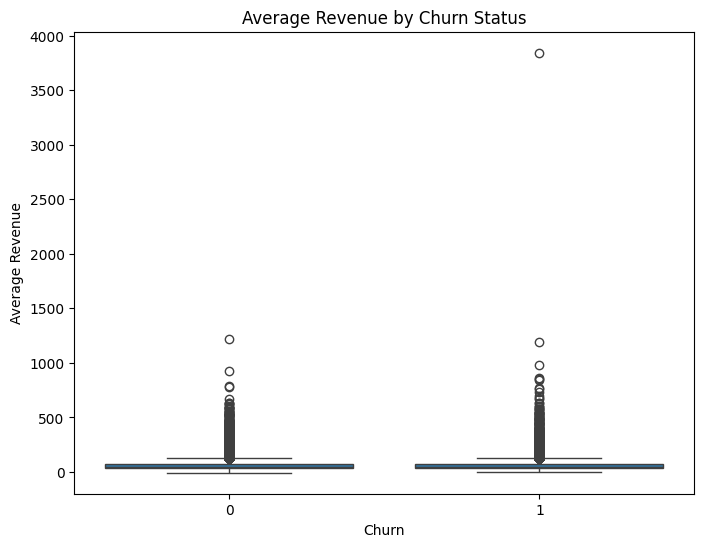

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='churn', y='rev_Mean', data=total_data)

plt.title('Average Revenue by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Revenue')
plt.show()

/tmp/ipykernel_1096/732556335.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_data.groupby('mrc_group')['churn']


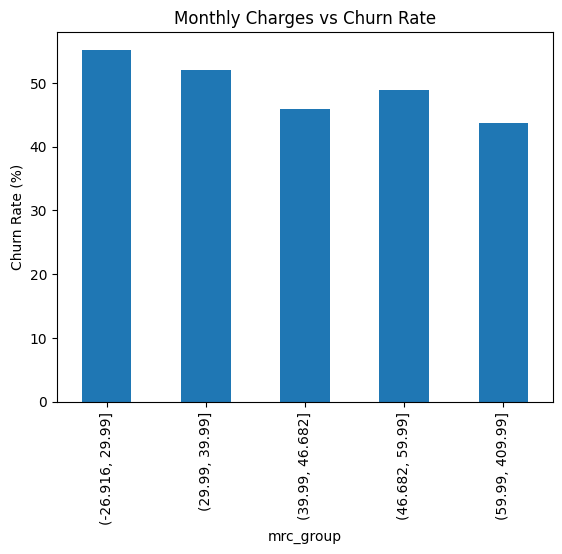

In [47]:
total_data['mrc_group'] = pd.qcut(
    total_data['totmrc_Mean'],
    q=5
)

churn_rate = (
    total_data.groupby('mrc_group')['churn']
    .mean()*100
)

churn_rate.plot(kind='bar')

plt.title('Monthly Charges vs Churn Rate')
plt.ylabel('Churn Rate (%)')
plt.show()

/tmp/ipykernel_1096/956849088.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_data.groupby('usage_group')['churn']


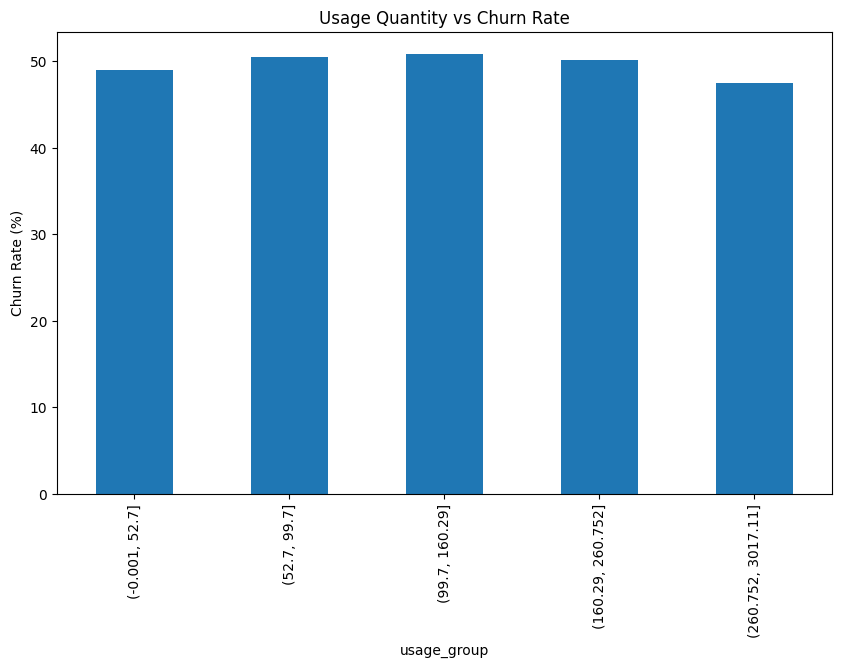

In [48]:
total_data['usage_group'] = pd.qcut(
    total_data['avgqty'],
    q=5
)

churn_rate = (
    total_data.groupby('usage_group')['churn']
    .mean()*100
)

plt.figure(figsize=(10,6))
churn_rate.plot(kind='bar')

plt.title('Usage Quantity vs Churn Rate')
plt.ylabel('Churn Rate (%)')
plt.show()

/tmp/ipykernel_1096/1315883124.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_data.groupby('avg6qty_group')['churn']


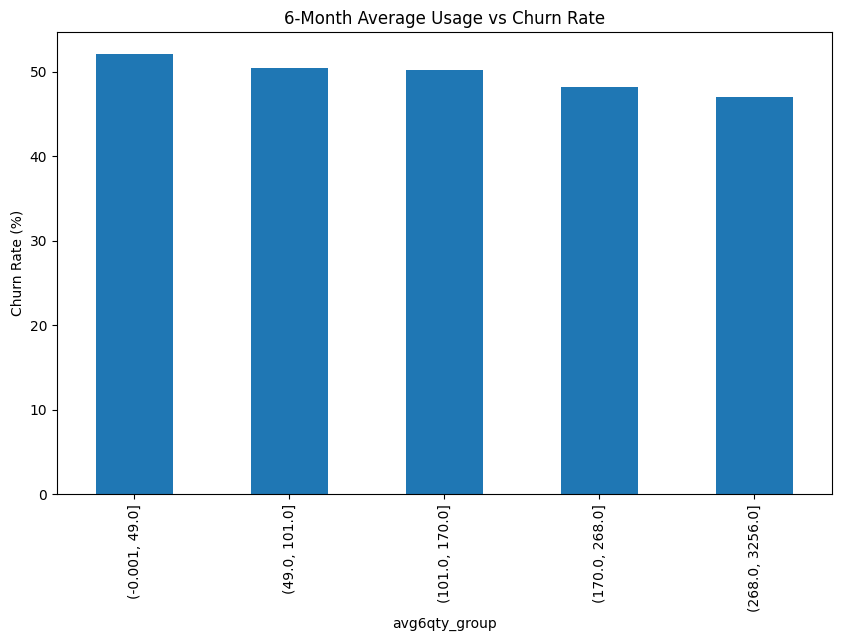

In [49]:
total_data['avg6qty_group'] = pd.qcut(
    total_data['avg6qty'],
    q=5
)

churn_rate = (
    total_data.groupby('avg6qty_group')['churn']
    .mean()*100
)

plt.figure(figsize=(10,6))
churn_rate.plot(kind='bar')

plt.title('6-Month Average Usage vs Churn Rate')
plt.ylabel('Churn Rate (%)')
plt.show()

In [50]:
# total_data['data_group'] = pd.qcut(
#     total_data['datovr_Mean'],
#     q=5,
#     duplicates='drop'
# )

# churn_rate = (
#     total_data.groupby('data_group')['churn']
#     .mean()*100
# )

# plt.figure(figsize=(10,6))
# churn_rate.plot(kind='bar')

# plt.title('Data Overage Charges vs Churn Rate')
# plt.ylabel('Churn Rate (%)')
# plt.show()

/tmp/ipykernel_1096/2038555077.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_data.groupby('totrev_group')['churn']


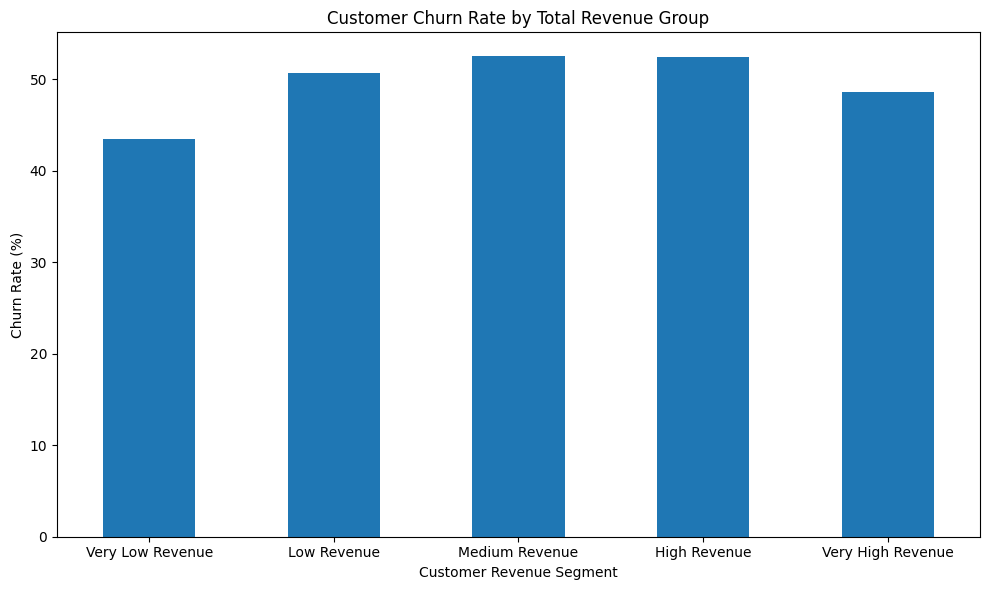

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Create revenue groups
total_data['totrev_group'] = pd.qcut(
    total_data['totrev'],
    q=5,
    labels=[
        'Very Low Revenue',
        'Low Revenue',
        'Medium Revenue',
        'High Revenue',
        'Very High Revenue'
    ]
)

# Calculate churn rate
churn_rate = (
    total_data.groupby('totrev_group')['churn']
    .mean() * 100
)

plt.figure(figsize=(10,6))
churn_rate.plot(kind='bar')

plt.title('Customer Churn Rate by Total Revenue Group')
plt.xlabel('Customer Revenue Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

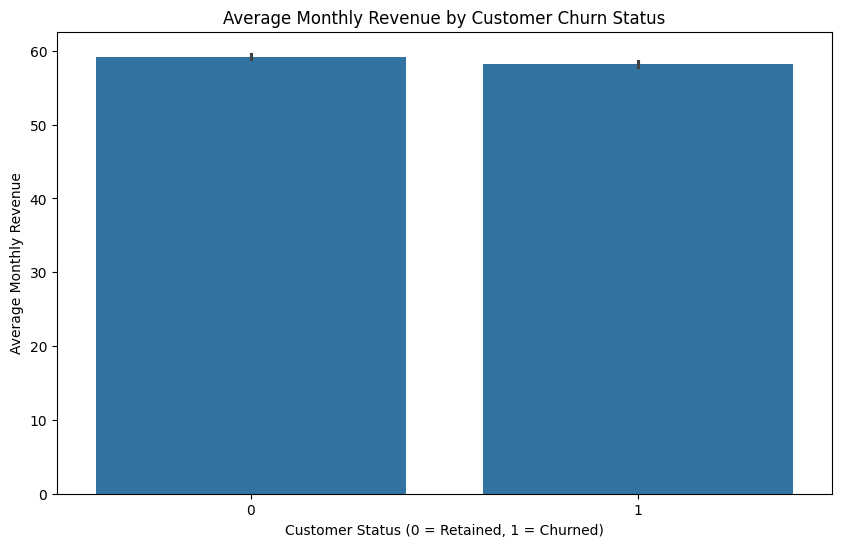

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    x='churn',
    y='rev_Mean',
    data=total_data
)

plt.title('Average Monthly Revenue by Customer Churn Status')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)')
plt.ylabel('Average Monthly Revenue')

plt.show()

/tmp/ipykernel_1096/2243320157.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_data.groupby('charge_group')['churn']


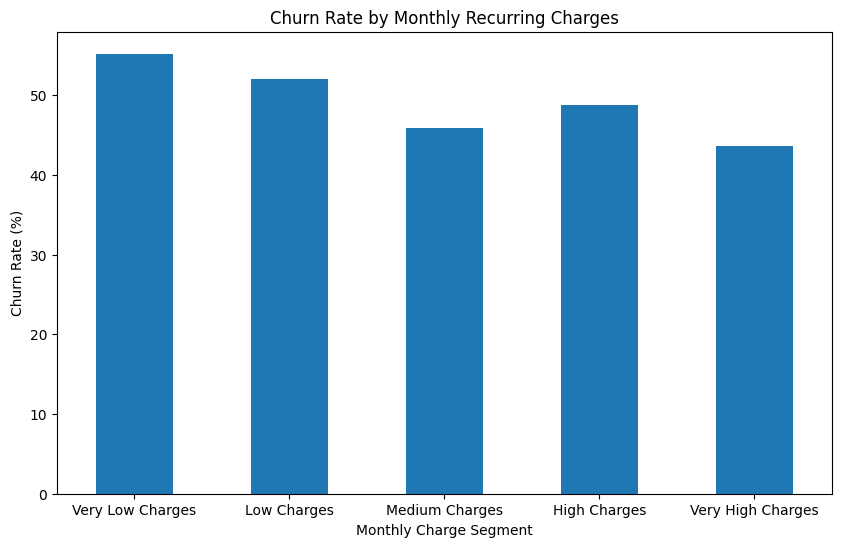

In [53]:
total_data['charge_group'] = pd.qcut(
    total_data['totmrc_Mean'],
    q=5,
    labels=[
        'Very Low Charges',
        'Low Charges',
        'Medium Charges',
        'High Charges',
        'Very High Charges'
    ]
)

charge_churn = (
    total_data.groupby('charge_group')['churn']
    .mean() * 100
)

plt.figure(figsize=(10,6))

charge_churn.plot(kind='bar')

plt.title('Churn Rate by Monthly Recurring Charges')
plt.xlabel('Monthly Charge Segment')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

plt.show()

/tmp/ipykernel_1096/4049051244.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_data.groupby('data_overage_group')['churn']


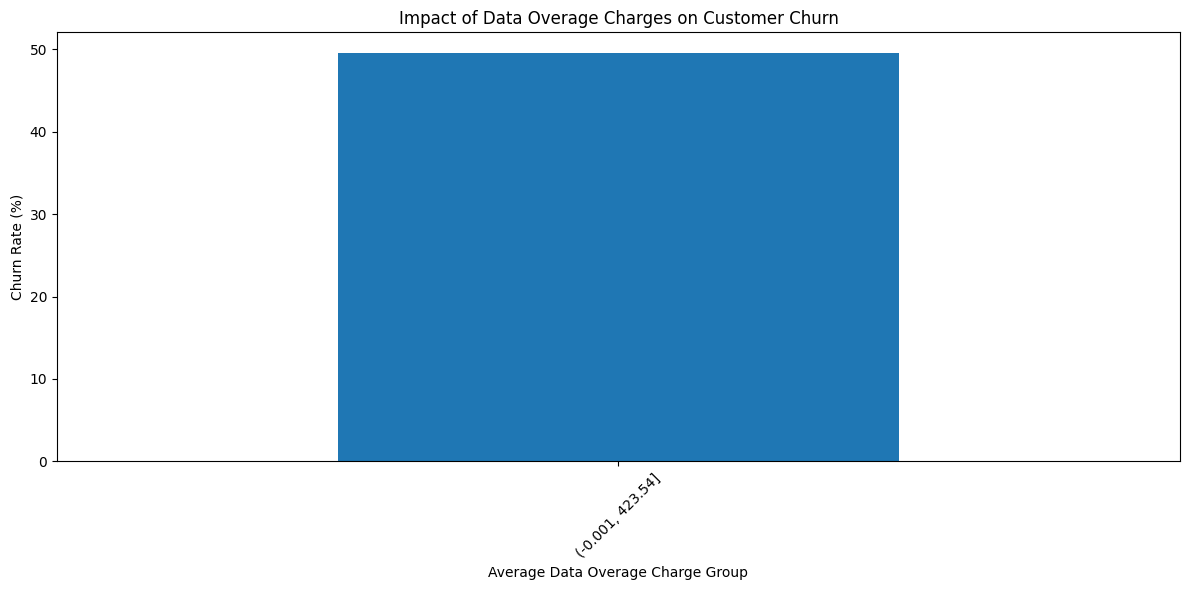

In [54]:
total_data['data_overage_group'] = pd.qcut(
    total_data['datovr_Mean'],
    q=5,
    duplicates='drop'
)

overage_churn = (
    total_data.groupby('data_overage_group')['churn']
    .mean() * 100
)

plt.figure(figsize=(12,6))

overage_churn.plot(kind='bar')

plt.title('Impact of Data Overage Charges on Customer Churn')
plt.xlabel('Average Data Overage Charge Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

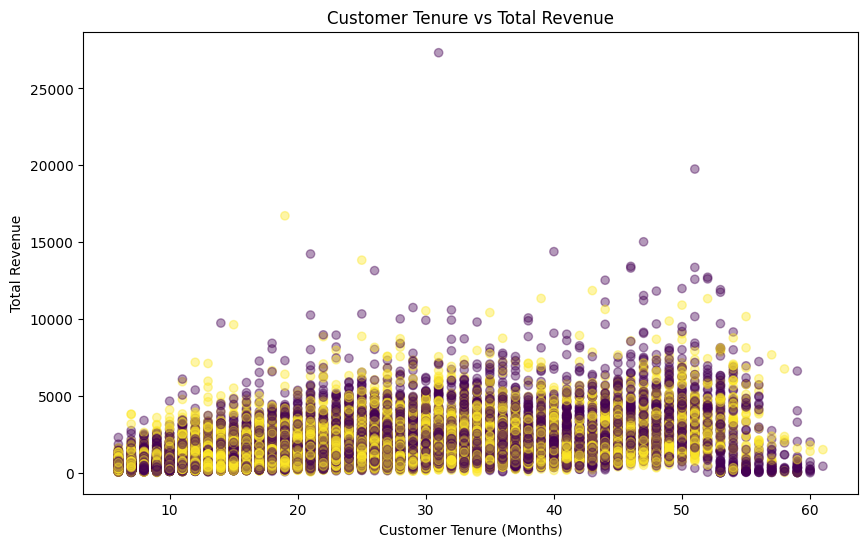

In [55]:
plt.figure(figsize=(10,6))

plt.scatter(
    total_data['months'],
    total_data['totrev'],
    alpha=0.4,
    c=total_data['churn']
)

plt.title('Customer Tenure vs Total Revenue')
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Total Revenue')

plt.show()

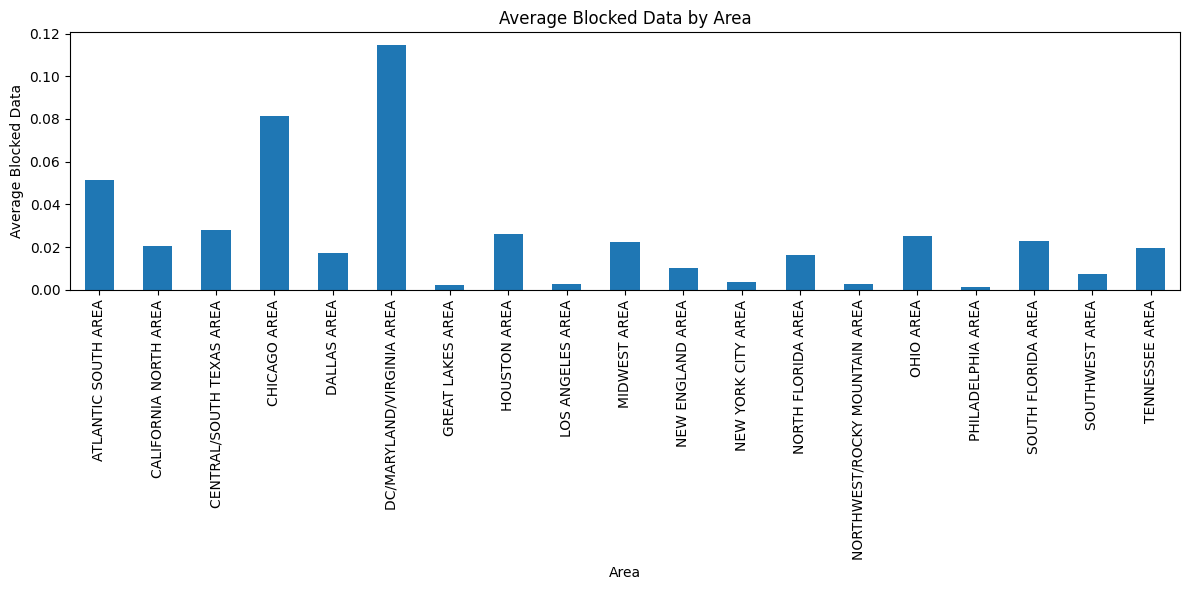

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

area_network = (
    total_data.groupby('area')['blck_dat_Mean']
    .mean()

    .head(19)
)

plt.figure(figsize=(12,6))

area_network.plot(kind='bar')

plt.title('Average Blocked Data by Area')
plt.xlabel('Area')
plt.ylabel('Average Blocked Data')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

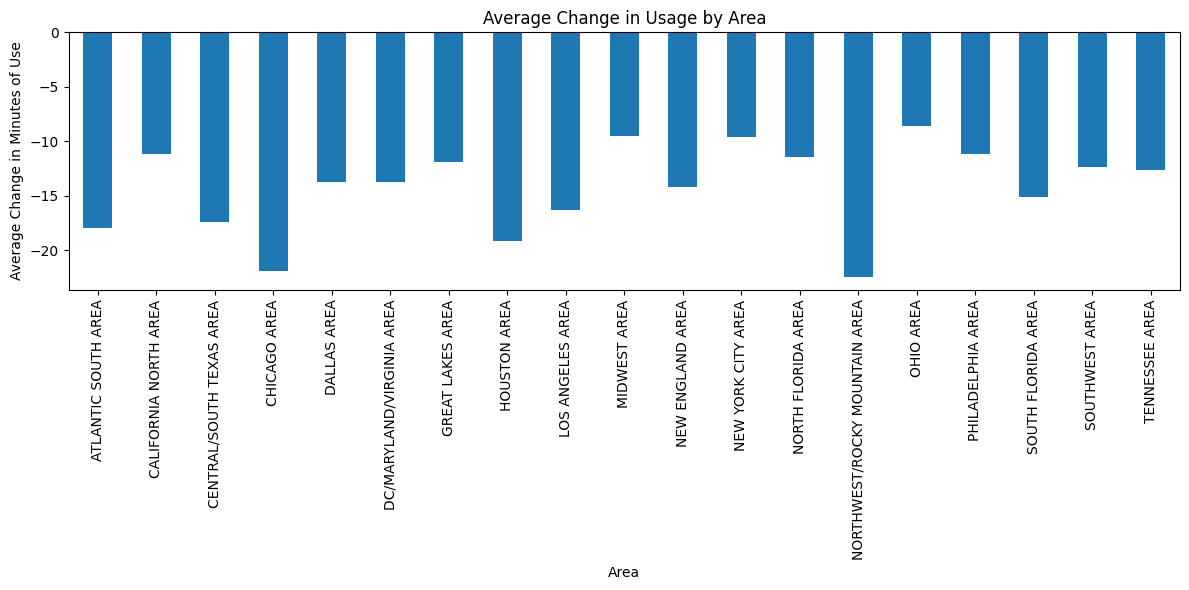

In [57]:
area_usage = (
    total_data.groupby('area')['change_mou']
    .mean()

)

plt.figure(figsize=(12,6))

area_usage.head(19).plot(kind='bar')

plt.title('Average Change in Usage by Area')
plt.xlabel('Area')
plt.ylabel('Average Change in Minutes of Use')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

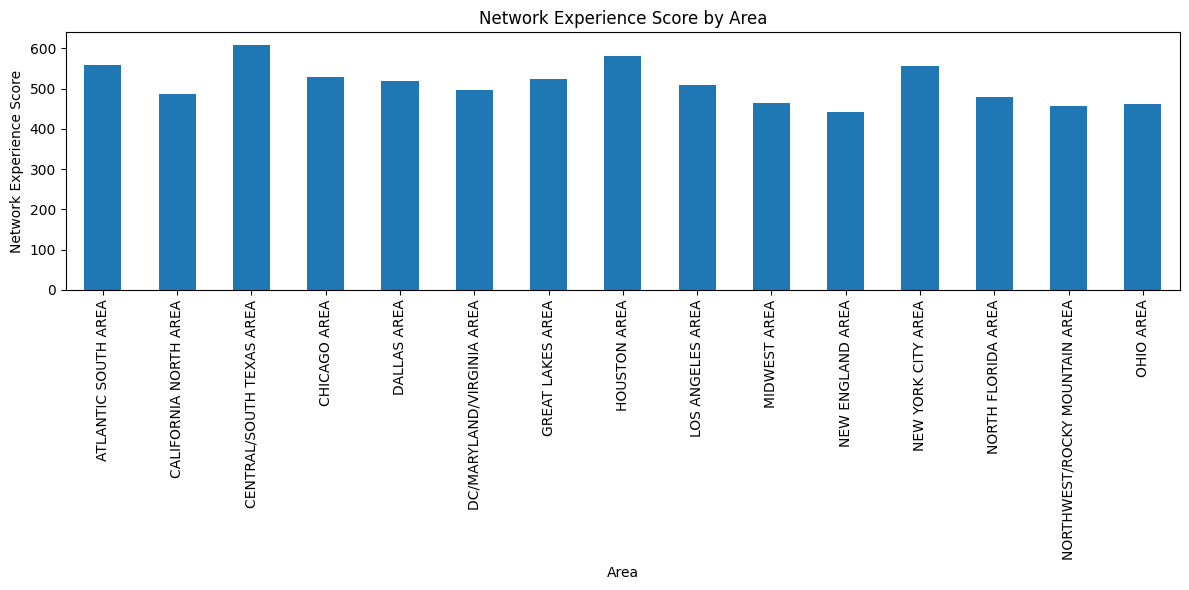

In [58]:
total_data['network_score'] = (
    total_data['mou_Mean']
    - total_data['blck_dat_Mean']
)

area_score = (
    total_data.groupby('area')['network_score']
    .mean()

)

plt.figure(figsize=(12,6))

area_score.head(15).plot(kind='bar')

plt.title('Network Experience Score by Area')
plt.xlabel('Area')
plt.ylabel('Network Experience Score')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1096/752707063.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_data.groupby('totrev_group')['churn']


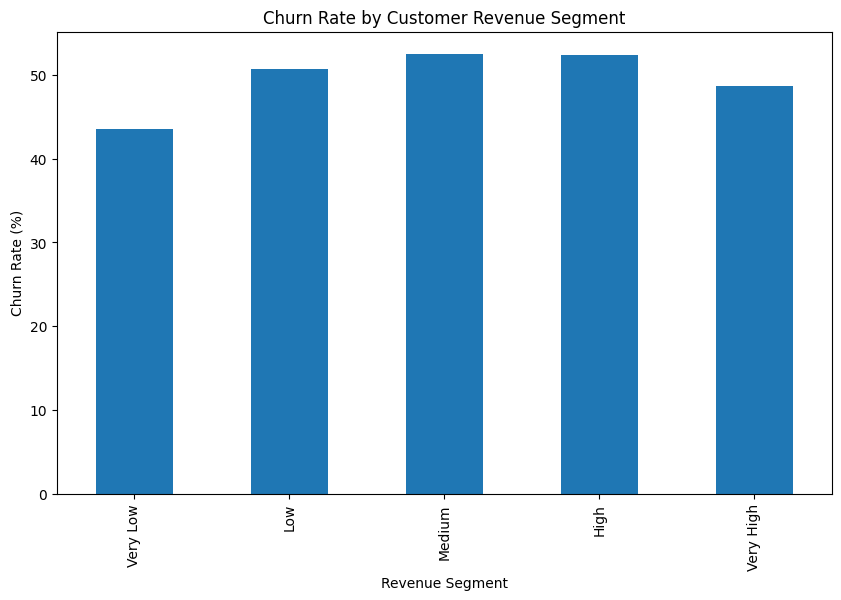

In [59]:
total_data['totrev_group'] = pd.qcut(
    total_data['totrev'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

churn_rate = (
    total_data.groupby('totrev_group')['churn']
    .mean()*100
)

plt.figure(figsize=(10,6))
churn_rate.plot(kind='bar')

plt.title('Churn Rate by Customer Revenue Segment')
plt.xlabel('Revenue Segment')
plt.ylabel('Churn Rate (%)')

plt.show()

# **CATEGORICAL ENCODING**

In [60]:
# Encoding of the categorical variables
multi_category_cols = ['actvsubs', 'new_cell', 'crclscod', 'prizm_social_one', 'area', 'marital', 'dwllsize', 'ethnic', 'forgntvl', 'truck', 'rv', 'ownrent', 'HHstatin', 'hnd_webcap']
binary=total_data[['asl_flag', 'dualband', 'refurb_new', 'dwlltype', 'creditcd']]
# Encodng for the binary columns
label_encoder = LabelEncoder()
for col in binary.columns:
    total_data[col] = label_encoder.fit_transform(total_data[col])
# Encoding of the multi-category columns
ohe=OneHotEncoder(handle_unknown='ignore', sparse_output=False)
dummy_encoded = ohe.fit_transform(total_data[multi_category_cols])
dummy_df = pd.DataFrame(dummy_encoded, columns=ohe.get_feature_names_out(multi_category_cols), index=total_data.index)
total_data = pd.concat([total_data.drop(columns=multi_category_cols), dummy_df], axis=1)

# **FEATURE ENGINEERING**

In [61]:
new_data=total_data[['churn', 'months', 'eqpdays', 'totmrc_Mean', 'asl_flag', 'refurb_new', 'dwlltype', 'hnd_price', 'dualband', 'creditcd', 'change_mou',  'adults', 'mou_pead_Mean', 'mouowylisv_Mean', 'mouiwylisv_Mean', 'opk_vce_Mean', 'income', 'unan_vce_Mean', 'mou_cvce_Mean', 'mou_peav_Mean', 'avg3qty', 'totrev', 'models', 'roam_Mean',  'datovr_Mean', 'owylis_vce_Mean',  'mou_Mean', 'avg6mou']]

In [62]:
new_data['revenue_per_month'] = (
    total_data['totrev'] /
    (total_data['months'] + 1)
)

/tmp/ipykernel_1096/311895778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['revenue_per_month'] = (


In [63]:
new_data['device_age_years'] = (
    total_data['eqpdays'] / 365
)

/tmp/ipykernel_1096/4215444870.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['device_age_years'] = (


In [64]:
new_data['usage_intensity'] = (
    total_data['mou_Mean'] /
    (total_data['months'] + 1)
)

/tmp/ipykernel_1096/1825150696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['usage_intensity'] = (


In [65]:
new_data['rev_ratio'] = (
    total_data['change_rev'] /
    (total_data['rev_Mean'] + 1)
)

/tmp/ipykernel_1096/151046032.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['rev_ratio'] = (


In [66]:
new_data['eqp_ratio'] = (
    total_data['eqpdays'] /
    (total_data['months']*30 + 1)
)

/tmp/ipykernel_1096/2473141397.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['eqp_ratio'] = (


# **MODEL TRAINING,BUILDING AND HYPERPARAMETER TUNNING**

---



In [67]:
X=new_data.drop('churn', axis=1)
y= new_data['churn']

In [68]:
# Identify categorical columns in X that are still objects (strings)
categorical_cols = X.select_dtypes(include='object').columns

# Apply One-Hot Encoding to identified categorical columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
models = {

    'RandomForest': {
        'pipeline': Pipeline([
            ('model', RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'model__n_estimators': [50, 100],
            'model__max_depth': [10, 20],
            'model__min_samples_split': [2, 5],
            'model__min_samples_leaf': [1, 2]
        }
    },

    'XGBoost': {
        'pipeline': Pipeline([
            ('model', XGBClassifier(
                random_state=42,
                eval_metric='logloss'
            ))
        ]),
        'params': {
            'model__n_estimators': [50, 100],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.1],
            'model__subsample': [0.8, 1.0]
        }
    },

    'LightGBM': {
        'pipeline': Pipeline([
            ('model', LGBMClassifier(random_state=42))
        ]),
        'params': {
            'model__n_estimators': [50, 100],
            'model__learning_rate': [0.01, 0.1],
            'model__max_depth': [-1, 10],
            'model__num_leaves': [31, 50]
        }
    },

    'CatBoost': {
        'pipeline': Pipeline([
            ('model', CatBoostClassifier(
                random_state=42,
                verbose=0, # Suppress CatBoost verbose output during grid search
                allow_writing_files=False # Prevents CatBoost from writing files to disk
            ))
        ]),
        'params': {
            'model__n_estimators': [50, 100],
            'model__learning_rate': [0.01, 0.1],
            'model__depth': [4, 6],
            'model__l2_leaf_reg': [1, 3]
        }
    },

    'MLPClassifier': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                random_state=42,
                max_iter=500
            ))
        ]),
        'params': {
            'model__hidden_layer_sizes': [
                (50,),
                (100,)
            ],
            'model__activation': ['relu', 'tanh'],
            'model__alpha': [0.001, 0.01],
            'model__learning_rate_init': [0.001, 0.01]
        }
    }
}

In [70]:
results = []

overall_best_estimator = None
overall_best_score = 0
overall_best_model_name = ""

for model_name, config in models.items():

    print(f"\nTraining {model_name}...")


    random_search = RandomizedSearchCV(
        estimator=config['pipeline'],
        param_distributions=config['params'],
        n_iter=5, # Reduced number of parameter settings to sample
        cv=2,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    print(f"Best Parameters: {random_search.best_params_}")
    print(f"Best CV Score: {random_search.best_score_:.4f}")

    results.append({
        'Model': model_name,
        'Best Score': random_search.best_score_,
        'Best Params': random_search.best_params_,
        'Best Estimator': random_search.best_estimator_ # Store the best estimator
    })

    if random_search.best_score_ > overall_best_score:
        overall_best_score = random_search.best_score_
        overall_best_estimator = random_search.best_estimator_
        overall_best_model_name = model_name


Training RandomForest...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 20}
Best CV Score: 0.6129

Training XGBoost...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.1}
Best CV Score: 0.6216

Training LightGBM...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
[LightGBM] [Info] Number of positive: 39583, number of negative: 40417
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5736
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 43
[LightGBM] [Info] [binary:Boo

In [71]:
results_df = pd.DataFrame(results)

print("\nModel Comparison")
print(results_df[['Model', 'Best Score', 'Best Params']].sort_values(
    by='Best Score',
    ascending=False
))

print(f"\nOverall Best Model: {overall_best_model_name} with Best CV Score: {overall_best_score:.4f}")


Model Comparison
           Model  Best Score  \
2       LightGBM    0.622437   
1        XGBoost    0.621613   
0   RandomForest    0.612938   
3       CatBoost    0.609875   
4  MLPClassifier    0.599025   

                                         Best Params  
2  {'model__num_leaves': 50, 'model__n_estimators...  
1  {'model__subsample': 0.8, 'model__n_estimators...  
0  {'model__n_estimators': 100, 'model__min_sampl...  
3  {'model__n_estimators': 50, 'model__learning_r...  
4  {'model__learning_rate_init': 0.01, 'model__hi...  

Overall Best Model: LightGBM with Best CV Score: 0.6224


In [72]:
from sklearn.metrics import classification_report

y_pred = overall_best_estimator.predict(X_test)

print("\nOverall Best Model Performance")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))




Overall Best Model Performance
Test Accuracy: 0.6269

Classification Report
              precision    recall  f1-score   support

           0       0.63      0.61      0.62     10021
           1       0.62      0.65      0.63      9979

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



<Figure size 1200x800 with 0 Axes>

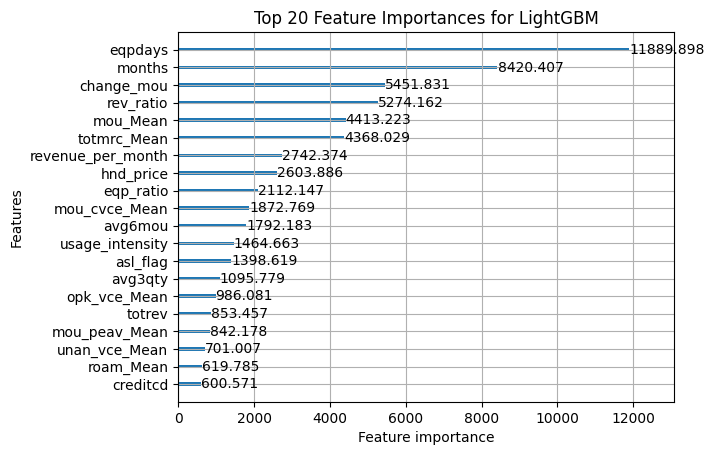

In [73]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Check if overall_best_estimator is defined and if LightGBM was the best model
if 'overall_best_estimator' in globals() and overall_best_model_name == 'LightGBM':
    plot_importance(
        overall_best_estimator.named_steps['model'],
        max_num_features=20,
        importance_type='gain'
    )
    plt.title(f'Top 20 Feature Importances for {overall_best_model_name}')
    plt.show()
else:
    print("LightGBM was not the overall best model, or overall_best_estimator is not defined.")
    print("Please ensure you have run the model training cells and LightGBM was selected as the best model.")

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


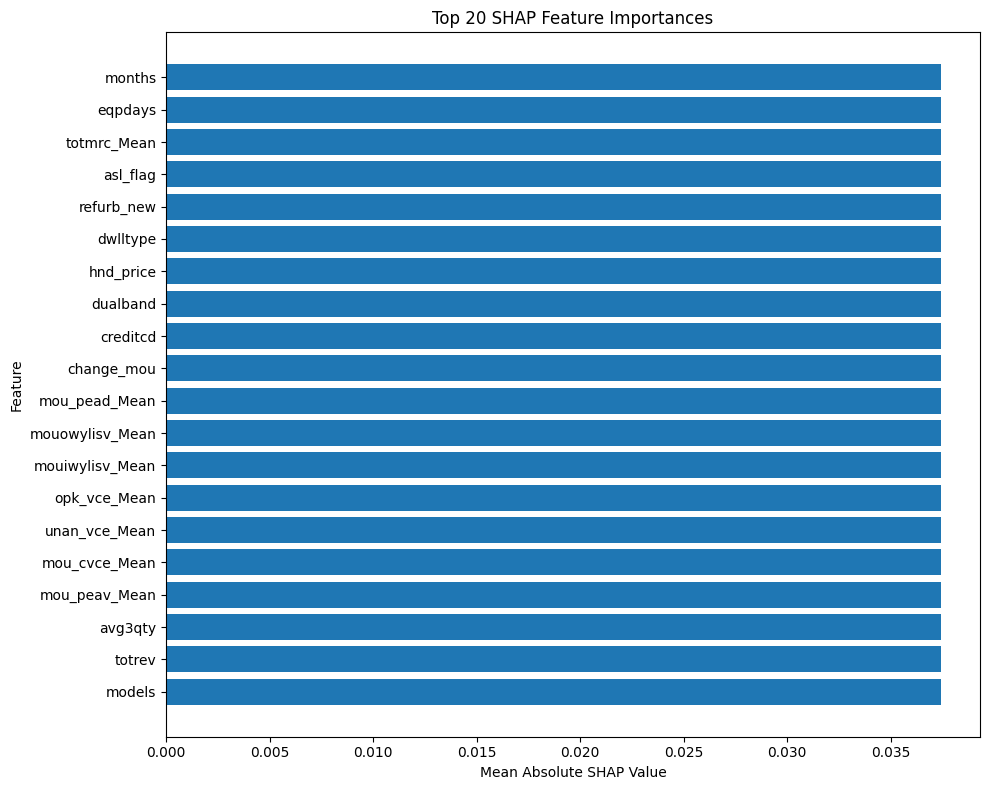

In [75]:
import matplotlib.pyplot as plt
import shap
import pandas as pd

# Calculate SHAP values for the best LightGBM model

explainer = shap.TreeExplainer(overall_best_estimator.named_steps['model'])
shap_values = explainer.shap_values(X_test)


# We typically use the absolute mean SHAP values for the positive class (index 1) for importance
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP Importance': np.abs(shap_values[1]).mean(axis=0)
}).sort_values(by='SHAP Importance', ascending=False)

top20 = shap_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'][::-1],
    top20['SHAP Importance'][::-1]
)

plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.title('Top 20 SHAP Feature Importances')

plt.tight_layout()
plt.show()

# **References**

Chang, V., Hall, K., Xu, Q. A., Amao, F. O., Ganatra, M. A., & Benson, V. (2024). Prediction of customer churn behavior in the telecommunication industry using machine learning models. Algorithms, 17(6), 231. https://doi.org/10.3390/a17060231

GSMA Intelligence. (2014). Mobile churn trends and customer retention strategies: Maintaining market share in the data-centric era. https://www.gsmaintelligence.com/research/mobile-churn-trends-and-customer-retention-strategies-maintaining-market-share-in-the-data-centric-era

McKinsey & Company. (2026). Winning B2B customers in technology and telecommunications. https://www.mckinsey.com/middle-east/our-insights/winning-b2b-customers-in-technology-and-telecommunications

Ribeiro, H., Barbosa, B., Moreira, A. C., & Rodrigues, R. G. (2024). Determinants of churn in telecommunication services: A systematic literature review. Management Review Quarterly, 74, 1327–1364. https://doi.org/10.1007/s11301-023-00335-7

Shaikhsurab, M. A., & Magadum, P. (2024). Enhancing customer churn prediction in telecommunications: An adaptive ensemble learning approach. arXiv. https://arxiv.org/abs/2408.16284

Ahmad, A. K., Jafar, A., & Aljoumaa, K. (2019). Customer churn prediction in telecom using machine learning and social network analysis in big data platform. arXiv. https://arxiv.org/abs/1904.00690